# Simple model

We simulate bursts with N=1 component and infer one parameter, the peak time (`t0`) with MCMC and normalizing flows.

In [65]:
import sys
sys.path.append('..')

import emcee
import numpy as np
import math 
import matplotlib.pyplot as plt
from typing import Iterable

from src.helpers import twoexp, combined_twoexp, simulate_burst, plot_simulated_burst

In [86]:
time = np.linspace(0, 2.0, 1000)
N = 1
amp = 10.0
t0 = 0.4
rise = 0.03
skew = 5.0

ybkg = 5.0

x_model, x_counts = simulate_burst(
    time=time,
    ncomp=N,
    burstparams=[t0, amp, rise, skew],
    ybkg=ybkg,
    return_model=True
)

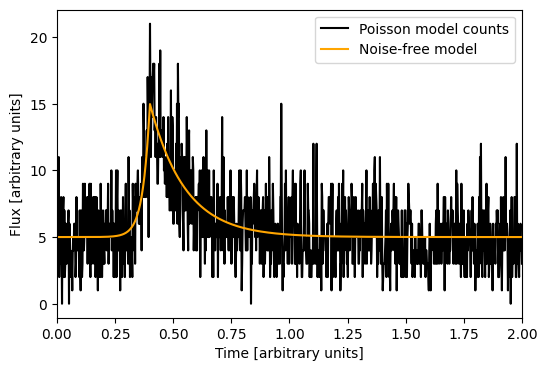

In [87]:
plot_simulated_burst(time, x_counts, x_model)
plt.show()

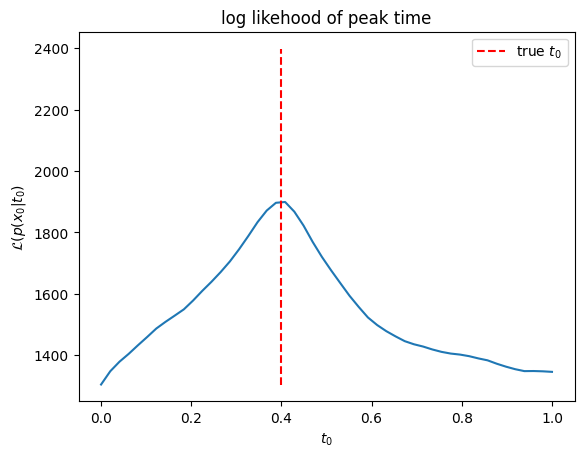

In [88]:
def log_likelihood(t0: float, x_counts: Iterable[int]) -> float:
    """
    $ln(p(x_{counts} | t0)$
    natural logarithm of poisson likelihood.
    """
    
    L = 0
    # true rate 
    model_counts = combined_twoexp(time, [t0], [amp], [rise], [skew], ybkg)

    L = (
        -1 * np.sum(np.log(model_counts)) 
        + np.sum(x_counts * np.log(model_counts)) 
        - np.sum([math.log(math.factorial(x)) for x in x_counts]) # Note x is simulated count and should always be integer
    )
    
    # TODO: Compare w/ likelihood function of Daniela
    return L

true_t0 = t0
t0s = np.linspace(0, 1, 50)
likelihoods = [log_likelihood(t0, x_counts) for t0 in t0s]
plt.plot(t0s, likelihoods)
plt.title("log likehood of peak time")
plt.ylabel("$\mathcal{L}(p(x_0 | t_0)$")
plt.xlabel("$t_0$")
plt.vlines([true_t0],  ymin=min(likelihoods), ymax=max(likelihoods) + 500, linestyles="dashed", color ='red', label='true $t_0$')
plt.legend()
plt.show()


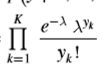

In [89]:
nwalkers = 20
ndim = 1
p0 = np.random.rand(nwalkers, ndim) # initial position of the walkers

def log_prob(t0: Iterable[float], *args) -> float:
    """
    Log of the posterior distribution.
    """
    # t0 is bounded by the uniform prior
    if t0 < 0 or t0 > 1:
        return -np.inf
    
    # otherwise its equal to the likelihood
    return log_likelihood(t0, *args)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[x_counts])

In [ ]:
# burn-in 
burn_steps = 300
state = sampler.run_mcmc(p0, burn_steps)
sampler.reset()

In [96]:
steps = 1000
sampler.run_mcmc(state, 1000)

State([[0.39980797]
 [0.39888958]
 [0.39544088]
 [0.3998435 ]
 [0.39994296]
 [0.39879774]
 [0.39511866]
 [0.39786363]
 [0.40057088]
 [0.40752642]
 [0.39738279]
 [0.40443573]
 [0.39799338]
 [0.40097962]
 [0.39705436]
 [0.40128946]
 [0.39875629]
 [0.39878884]
 [0.40058789]
 [0.39742181]], log_prob=[1902.21390121 1902.06944876 1900.9285477  1902.22110197 1902.24189235
 1902.05942281 1900.79376772 1901.81742934 1902.30394121 1899.7067523
 1901.65328663 1901.27760806 1901.86540007 1902.20623971 1901.55354372
 1902.14320531 1902.0551611  1902.05849432 1902.29954535 1901.66580692], blobs=None, random_state=('MT19937', array([2048648254, 1155933073, 4023071879, 2266456937,  896870836,
       1388086959, 3946903479, 4226001993, 4064179261, 2721919679,
       3279926072, 2367402001, 3323414550, 1404598100,  973245743,
       2385861859, 3446281301,  999764679, 4037836638, 1720778130,
        308031976, 1941226166,  849629902,  336333363, 3025412127,
        913434419, 1371699082, 3538236744,  27

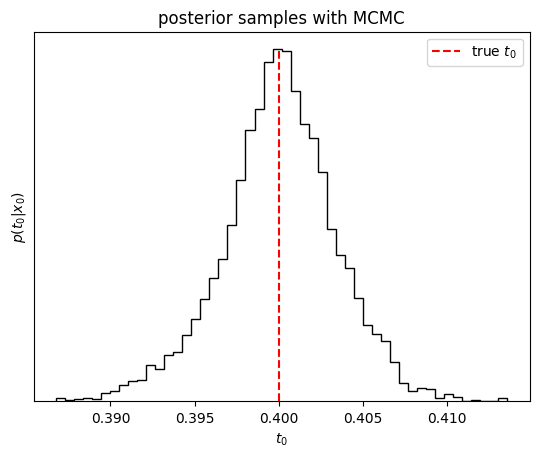

In [97]:
samples = sampler.get_chain(flat=True)

frequencies, _, _ = plt.hist(samples[:, 0], 50, color="k", histtype="step")
plt.vlines([true_t0],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_0$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

In [98]:
print(
    "Mean acceptance fraction: {0:.3f}".format(
        np.mean(sampler.acceptance_fraction)
    )
)

# TODO: Diagnose mcmc Trace plots chains as a func of iteration (ideally should be white noise)
# Autocorrelation time check
# add plots where you overlay samples from the posterior on the data

Mean acceptance fraction: 0.803


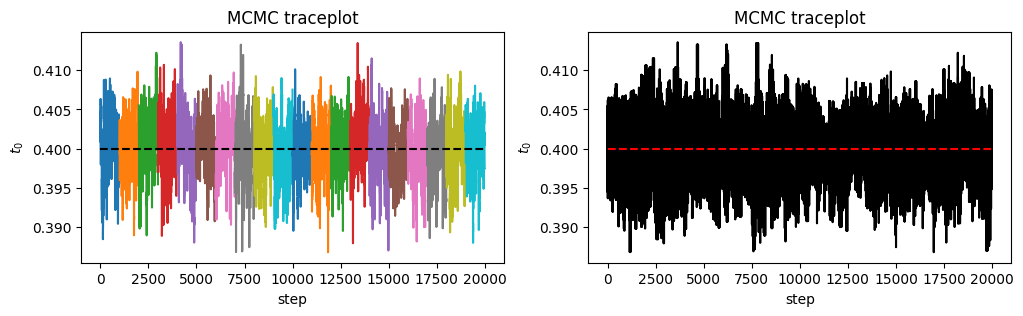

In [99]:
# trace plot
plt.figure(figsize=(12,3))

# each walker a different color
plt.subplot(121)
for i, walker in enumerate(sampler.get_chain().reshape((1000,20)).T):
    start = int(i * steps)
    plt.plot(range(start, start + steps), walker)
    
plt.title("MCMC traceplot")
plt.xlabel("step")
plt.ylabel("$t_0$")
plt.hlines([true_t0], xmin=0, xmax=nwalkers*steps, linestyle='dashed', color='black')

# walkers back to back
plt.subplot(122)
plt.plot(sampler.get_chain(flat=True), 'k-')
plt.title("MCMC traceplot")
plt.xlabel("step")
plt.ylabel("$t_0$")
plt.hlines([true_t0], xmin=0, xmax=nwalkers*steps, linestyle='dashed', color='red')
plt.show()

# Two peaks

In [8]:
time = np.linspace(0, 1, 1000)
N = 2
amp = 20.0
t0 = 0.1
rise = 0.03
skew = 5.0

ybkg = 5.0

t0_l = [t0, t0+0.5]
rise_l = [rise, rise]
amp_l = [amp, amp] 
skew_l = [skew, skew] 

burstparams = np.array([t0_l, amp_l, rise_l, skew_l]).flatten()

x_model, x_counts = simulate_burst(
    time=time,
    ncomp=N,
    burstparams=burstparams,
    ybkg=ybkg,
    return_model=True
)

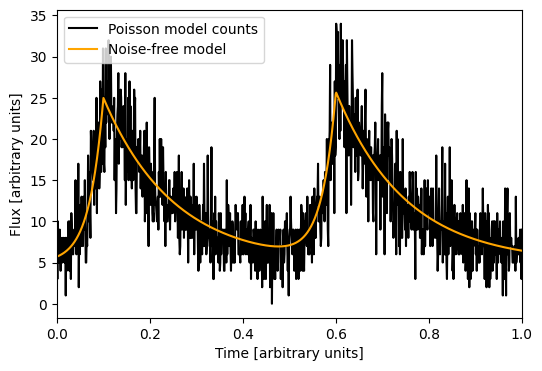

In [9]:
plot_simulated_burst(time, x_counts, x_model)
plt.show()

In [12]:
nwalkers = 20
ndim = 2
p0 = np.random.rand(nwalkers, ndim) # initial position of the walkers

def log_likelihood(t0, x_counts):
    """
    $ln(p(x_{counts} | t0)$
    natural logarithm of poisson likelihood.
    """
    
    L = 0
    # true rate 
    model_counts = combined_twoexp(time, t0, [amp, amp], [rise, rise], [skew, skew], ybkg)

    L = (
        -1 * np.sum(np.log(model_counts)) 
        + np.sum(x_counts * np.log(model_counts)) 
        - np.sum([math.log(math.factorial(x)) for x in x_counts]) # TODO: If x is float, change m.factorial(x), m.gamma(x + 1)
    )
    
    # TODO: Compare w/ likelihood function of Daniela
    return L

def log_prob(t0, *args):
    """
    Log of the posterior distribution.
    """
    # t0 is bounded by the uniform prior
    if t0.any() < 0 or t0.any() > 1:
        return -np.inf
    
    # otherwise its equal to the likelihood
    return log_likelihood(t0, *args)

# https://emcee.readthedocs.io/en/stable/tutorials/quickstart/
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=[x_counts])

In [13]:
# burn-in of 100 steps
state = sampler.run_mcmc(p0, 300)
sampler.reset()
sampler.run_mcmc(state, 1000)

State([[0.60186138 0.1005935 ]
 [0.59805557 0.0983056 ]
 [0.59996462 0.09843892]
 [0.09831967 0.60047028]
 [0.60066743 0.10164832]
 [0.09870414 0.60145828]
 [0.09835546 0.60075428]
 [0.09873104 0.59909925]
 [0.60016281 0.09966425]
 [0.60085997 0.09900833]
 [0.60198376 0.10214627]
 [0.60092885 0.10137364]
 [0.10165825 0.60147861]
 [0.59947109 0.10160611]
 [0.10059872 0.60165552]
 [0.10044197 0.60008355]
 [0.10204027 0.59822546]
 [0.60077326 0.09851672]
 [0.1026241  0.59958674]
 [0.10185331 0.6001524 ]], log_prob=[6939.87305678 6938.28179177 6939.83844682 6940.0262653  6939.74983993
 6940.12358694 6940.06918124 6939.47636021 6940.3684517  6940.49105151
 6938.83033943 6939.86104722 6939.54639905 6939.18779263 6940.08506512
 6940.16833432 6937.84114597 6940.16466867 6938.48439931 6939.38183594], blobs=None, random_state=('MT19937', array([3065829307, 4002054562, 2653457436, 4074807915, 2824458539,
       2772836894,  283503335, 2793919359, 3298427953, 3043580304,
       2323531965, 1617947

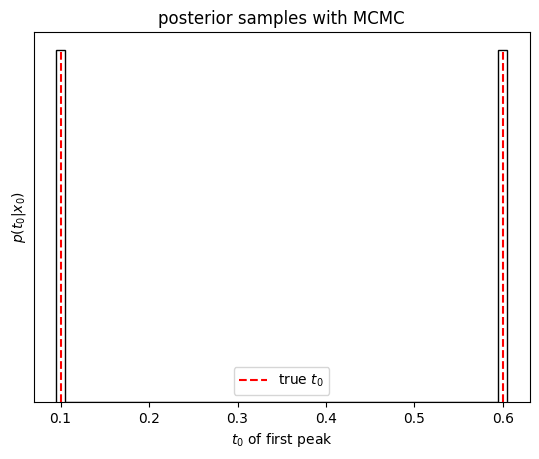

array([[0.59815803, 0.0985563 ],
       [0.59959332, 0.09854859],
       [0.60270181, 0.10127145],
       ...,
       [0.60077326, 0.09851672],
       [0.1026241 , 0.59958674],
       [0.10185331, 0.6001524 ]])

In [18]:
samples = sampler.get_chain(flat=True)

frequencies, _, _ = plt.hist(samples[:, 0], 50, color="k", histtype="step")
plt.vlines([0.1, 0.6],  ymin=0, ymax=max(frequencies), linestyles="dashed", color ='red', label='true $t_0$')

plt.title("posterior samples with MCMC")
plt.xlabel("$t_0$ of first peak")
plt.ylabel("$p(t_0 | x_0)$")
plt.gca().set_yticks([])

plt.legend()
plt.show()

samples

In [ ]:
# Normalizing flow

# generate bunch of training data (all params fixed except t0?)

# generate posterior using normalizing flow ?

6.0 6
